# **Graph Workflows**

## **What's Covered?**
1. Sequential Graph

## **Sequential Graph**

In [1]:
from typing import TypedDict

# Define a State
class TemperatureState(TypedDict):
    fahrenheit: float      # Input
    celsius: float         # Output
    climate_label: str     # Status

In [2]:
# Step 2: Defining graph nodes

def fahrenheit2celsius_converter(state: TemperatureState) -> TemperatureState:
    f_temp = state["fahrenheit"]
    
    # CALCULATE
    c_temp = (f_temp - 32) * 5/9

    # WRITE the update
    state["celsius"] = round(c_temp, 2)
    
    # RETURN the state
    return state

def climate_label(state: TemperatureState) -> TemperatureState:
    c_temp = state["celsius"]

    if c_temp < 0:
        state["climate_label"] = "Below Freezing Point"
    elif c_temp == 0:
        state["climate_label"] = "Freezing Point"
    elif 0 < c_temp <= 15:
        state["climate_label"] = "Cold"
    elif 15 < c_temp <= 25:
        state["climate_label"] = "Pleasant"
    elif 25 < c_temp <= 35:
        state["climate_label"] = "Hot"
    else:
        state["climate_label"] = "Heatwave"

    return state

In [3]:
# Step 3: Define a Graph

from langgraph.graph import StateGraph, START, END

graph = StateGraph(TemperatureState)

graph.add_node("f2c_node", fahrenheit2celsius_converter)
graph.add_node("labeler_node", climate_label)

graph.add_edge(START, "f2c_node")
graph.add_edge("f2c_node", "labeler_node")
graph.add_edge("labeler_node", END)

In [4]:
# Step 4: Compile the graph

workflow = graph.compile()

In [5]:
workflow.invoke({"fahrenheit": 32})

{'fahrenheit': 32, 'celsius': 0.0, 'climate_label': 'Freezing Point'}

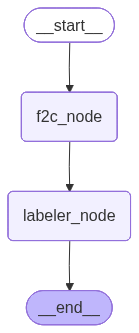

In [6]:
# Visualize the Graph

from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

### **New Construct for Sequential Graph**

```python
builder = StateGraph(OverallState).add_sequence([node_1, node_2, node_3])
```